## Urszula Michalska, Natalia Rogalska


In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import time

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [5]:
cat = CatBoostClassifier(iterations=5000)

param_grid = {
    'depth':[4,6,8,10],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'iterations':[300,500,1000,2000],
    'l2_leaf_reg':[1,3,5,10],
    'random_strength':[0,1,5],
    'border_count':[32,64,128],
    'bagging_temperature':[0,0.5,1],
}

start = time.perf_counter()

cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

cat.fit(X_train, y_train)

end = time.perf_counter()
print(f"Elapsed time: {end - start:.6f} seconds")

0:	learn: 1.0770975	total: 154ms	remaining: 2m 34s
1:	learn: 1.0567167	total: 173ms	remaining: 1m 26s
2:	learn: 1.0352000	total: 191ms	remaining: 1m 3s
3:	learn: 1.0182778	total: 209ms	remaining: 52s
4:	learn: 1.0009839	total: 227ms	remaining: 45.1s
5:	learn: 0.9846536	total: 245ms	remaining: 40.6s
6:	learn: 0.9698846	total: 263ms	remaining: 37.3s
7:	learn: 0.9520665	total: 279ms	remaining: 34.6s
8:	learn: 0.9408333	total: 293ms	remaining: 32.2s
9:	learn: 0.9278283	total: 302ms	remaining: 29.9s
10:	learn: 0.9160066	total: 310ms	remaining: 27.9s
11:	learn: 0.9026212	total: 316ms	remaining: 26s
12:	learn: 0.8893924	total: 322ms	remaining: 24.5s
13:	learn: 0.8779634	total: 328ms	remaining: 23.1s
14:	learn: 0.8668561	total: 333ms	remaining: 21.9s
15:	learn: 0.8575114	total: 339ms	remaining: 20.8s
16:	learn: 0.8466278	total: 344ms	remaining: 19.9s
17:	learn: 0.8372994	total: 350ms	remaining: 19.1s
18:	learn: 0.8277772	total: 355ms	remaining: 18.3s
19:	learn: 0.8182179	total: 360ms	remaining

In [6]:
start = time.perf_counter()

cat_best = CatBoostClassifier(**cat.best_params_)
cat_best.fit(X_train, y_train)
cat_best.score(X_test,y_test)

end = time.perf_counter()
print(f"Elapsed time: {end - start:.6f} seconds")


0:	learn: 1.0770975	total: 39.8ms	remaining: 39.8s
1:	learn: 1.0567167	total: 69.8ms	remaining: 34.8s
2:	learn: 1.0352000	total: 101ms	remaining: 33.5s
3:	learn: 1.0182778	total: 123ms	remaining: 30.7s
4:	learn: 1.0009839	total: 138ms	remaining: 27.5s
5:	learn: 0.9846536	total: 148ms	remaining: 24.6s
6:	learn: 0.9698846	total: 155ms	remaining: 22.1s
7:	learn: 0.9520665	total: 163ms	remaining: 20.2s
8:	learn: 0.9408333	total: 169ms	remaining: 18.6s
9:	learn: 0.9278283	total: 175ms	remaining: 17.3s
10:	learn: 0.9160066	total: 181ms	remaining: 16.2s
11:	learn: 0.9026212	total: 186ms	remaining: 15.3s
12:	learn: 0.8893924	total: 191ms	remaining: 14.5s
13:	learn: 0.8779634	total: 197ms	remaining: 13.9s
14:	learn: 0.8668561	total: 202ms	remaining: 13.3s
15:	learn: 0.8575114	total: 207ms	remaining: 12.7s
16:	learn: 0.8466278	total: 212ms	remaining: 12.3s
17:	learn: 0.8372994	total: 218ms	remaining: 11.9s
18:	learn: 0.8277772	total: 223ms	remaining: 11.5s
19:	learn: 0.8182179	total: 228ms	remai

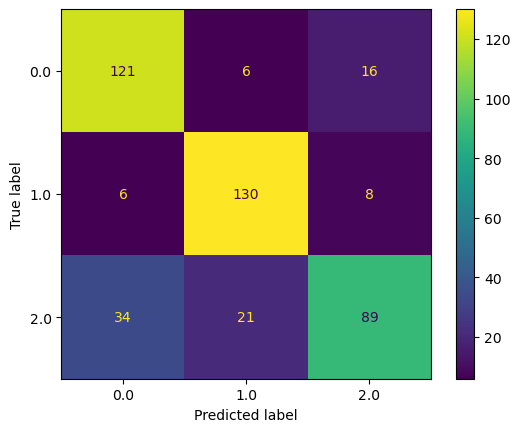

In [6]:
y_pred_best = cat_best.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best, labels=cat_best.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cat_best.classes_)
disp.plot()

In [7]:
class_report = classification_report(y_test, y_pred_best)
print("Classification Report:")
print(class_report)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best)}")

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.85      0.80       143
         1.0       0.83      0.90      0.86       144
         2.0       0.79      0.62      0.69       144

    accuracy                           0.79       431
   macro avg       0.79      0.79      0.78       431
weighted avg       0.79      0.79      0.78       431

Accuracy: 0.7888631090487239
